In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')



In [2]:
from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split

In [3]:
df = pd.read_csv('../data/processed/processed_data.csv', parse_dates=['Date'])

MACRO_COLS = [
    'CPI_Change', 'Rate_Change', 'GDP_Growth',
    'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread'
]

LAGGED_COLS = [
    'CPI_Change_lag1',
    'GDP_Growth_lag2',
    'Unemp_Change_lag1',
    'Credit_Spread_lag2'
]

ALL_COLS = MACRO_COLS + LAGGED_COLS

splits_data = data_split(df, ALL_COLS)
X_train= splits_data['X_train']
y_train     = splits_data['y_train']
X_test  = splits_data['X_test']
y_test      = splits_data['y_test']
dates_test = splits_data['dates_test']

TARGET = 'SP500_Return'



  Train       n= 334  1991-03-01 to 2018-12-01  μ=0.58%  σ=4.09%

  Test        n=  81  2019-01-01 to 2025-09-01  μ=1.21%  σ=4.85%

  Features (11): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread, CPI_Change_lag1, GDP_Growth_lag2, Unemp_Change_lag1, Credit_Spread_lag2


In [4]:
print("── Building XGBoost DMatrix ──")

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=ALL_COLS)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=ALL_COLS)

print(f"  dtrain : {dtrain.num_row()} rows × {dtrain.num_col()} features")
print(f"  dtest  : {dtest.num_row()} rows × {dtest.num_col()} features")

── Building XGBoost DMatrix ──
  dtrain : 334 rows × 11 features
  dtest  : 81 rows × 11 features


params = {

    'objective'        : 'reg:squarederror',
    'max_depth'        : 2,
    'min_child_weight' : 10,
    'learning_rate'    : 0.01,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'gamma'            : 0.1,
    'subsample'        : 0.8,

    'colsample_bytree' : 0.8,

    'colsample_bylevel': 1.0,
    'tree_method'      : 'hist',
    'seed'             : 42,
}

In [5]:
print("\n── Training XGBoost with Cross-Validation ──")
# For small datasets, cross-validation is preferred over a validation split
# to make the most of all available training data.

N_ROUNDS     = 1000   # maximum rounds — CV-based early stopping will cut this short
EARLY_STOP   = 50     # stop if no improvement for 50 rounds
VERBOSE_FREQ = 100    # print progress every 100 rounds
N_FOLDS      = 5      # 5-fold CV → each fold ~72 samples for validation

print(f"  Training samples : {len(X_train)}")
print(f"  Test samples     : {len(X_test)}")
print(f"  Max rounds       : {N_ROUNDS}")
print(f"  Early stopping   : {EARLY_STOP} rounds without improvement")
print(f"  CV folds         : {N_FOLDS}")
print(f"  Metric watched   : RMSE (mean across folds)\n")

# Run cross-validation to find the optimal number of boosting rounds
cv_results = xgb.cv(
    params            = params,
    dtrain            = dtrain,
    num_boost_round   = N_ROUNDS,
    nfold             = N_FOLDS,
    metrics           = 'rmse',
    early_stopping_rounds = EARLY_STOP,
    verbose_eval      = VERBOSE_FREQ,
    seed              = 42,
)

# Extract optimal number of rounds from CV results
best_round = len(cv_results)                          # rounds before early stop triggered
best_score = cv_results['test-rmse-mean'].min()       # best mean CV RMSE
best_std   = cv_results.loc[cv_results['test-rmse-mean'].idxmin(), 'test-rmse-std']

print(f"\n  CV complete — now training final model on ALL training data...")
print(f"     Optimal rounds (from CV) : {best_round}")
print(f"     Best CV RMSE             : {best_score:.4f}% ± {best_std:.4f}%")
print(f"     Rounds saved by early stop: {N_ROUNDS - best_round}\n")

# Store evaluation history for learning curves
evals_result = {}

# Train final model on the FULL training set using the optimal round count
model = xgb.train(
    params          = params,
    dtrain          = dtrain,
    num_boost_round = best_round,        # use CV-tuned round count, no early stopping needed
    evals           = [(dtrain, 'train')],
    evals_result    = evals_result,
    verbose_eval    = VERBOSE_FREQ,
)

print(f"\n  ✅ Final model trained!")
print(f"     Trees built              : {best_round}")
print(f"     Best CV RMSE             : {best_score:.4f}% ± {best_std:.4f}%")


── Training XGBoost with Cross-Validation ──
  Training samples : 334
  Test samples     : 81
  Max rounds       : 1000
  Early stopping   : 50 rounds without improvement
  CV folds         : 5
  Metric watched   : RMSE (mean across folds)



NameError: name 'params' is not defined

In [ ]:
print("\n── Generating Predictions ──")

# ntree_limit = best_round to use optimal # of trees
# Without this, XGBoost uses ALL trees (which may overfit)
y_pred_train = model.predict(dtrain, iteration_range=(0, best_round))
y_pred_test  = model.predict(dtest,  iteration_range=(0, best_round))

print(f"  Predictions generated for all 3 splits using {best_round} trees")


── Generating Predictions ──
  Predictions generated for all 3 splits using 605 trees


In [ ]:

print("\n── Performance Metrics ──")

def evaluate_split(y_true, y_pred, label):
    """Compute and print all key metrics for one data split."""
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    n       = len(y_true)

    r2      = r2_score(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred))

    # Directional accuracy interpretation
    da_label = ('beats random' if dir_acc > 0.55
                else 'marginal'  if dir_acc > 0.50
                else 'below random')
    print(f"  {label} Metrics:")  
    print(f"     R²                 : {r2:+.4f}")
    print(f"     RMSE               : {rmse:.4f}%")
    print(f"     MAE                : {mae:.4f}%")
    print(f"     Directional Acc    : {dir_acc:.4f}  {da_label}")
    return {'label': label, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'Dir_Acc': dir_acc}

train_m = evaluate_split(y_train, y_pred_train, "TRAIN  (1990 → 2019)")
test_m  = evaluate_split(y_test,  y_pred_test,  "TEST   (2020 → 2025)")







── Performance Metrics ──
  TRAIN  (1990 → 2019) Metrics:
     R²                 : +0.4961
     RMSE               : 2.8972%
     MAE                : 2.1670%
     Directional Acc    : 0.7890  beats random
  TEST   (2020 → 2025) Metrics:
     R²                 : +0.3173
     RMSE               : 4.1468%
     MAE                : 3.1568%
     Directional Acc    : 0.7101  beats random


In [ ]:
print("\n── Feature Importance ──")

importance_gain   = model.get_score(importance_type='gain')
importance_weight = model.get_score(importance_type='weight')

imp_df = pd.DataFrame({
    'Feature'  : list(importance_gain.keys()),
    'Gain'     : list(importance_gain.values()),
    'Weight'   : [importance_weight.get(f, 0) for f in importance_gain.keys()]
}).sort_values('Gain', ascending=True)

# Normalise to 0-100 for readability
imp_df['Gain_pct']   = imp_df['Gain']   / imp_df['Gain'].sum()   * 100
imp_df['Weight_pct'] = imp_df['Weight'] / imp_df['Weight'].sum() * 100

print(f"\n  {'Feature':<25} {'Gain (%)':>10}  {'Weight (%)':>12}  Visual")
print(f"  {'-'*25} {'-'*10}  {'-'*12}  ------")
for _, row in imp_df.iterrows():
    bar = '█' * int(row['Gain_pct'] / 2)
    print(f"  {row['Feature']:<25} {row['Gain_pct']:>10.2f}  "
          f"{row['Weight_pct']:>12.2f}  {bar}")

# Features not used at all
unused = [f for f in ALL_COLS if f not in importance_gain]
if unused:
    print(f"\n  Features NOT used in any split: {unused}")
    print(f"These contribute nothing. Consider dropping them in above step.")





── Feature Importance ──

  Feature                     Gain (%)    Weight (%)  Visual
  ------------------------- ----------  ------------  ------
  CPI_Change_lag1                 5.62          5.66  ██
  Unemp_Change                    6.15          2.76  ███
  CPI_Change                      6.51          6.91  ███
  GDP_Growth_lag2                 7.10          7.17  ███
  Rate_Change                     7.16          9.67  ███
  Unemp_Change_lag1               7.85          4.21  ███
  Credit_Spread_lag2              8.38          9.21  ████
  GDP_Growth                      8.46          5.99  ████
  USD_Change                      9.43         11.58  ████
  Credit_Spread                   9.48          8.49  ████
  VIX_Change                     23.85         28.36  ███████████


**Plotting results**


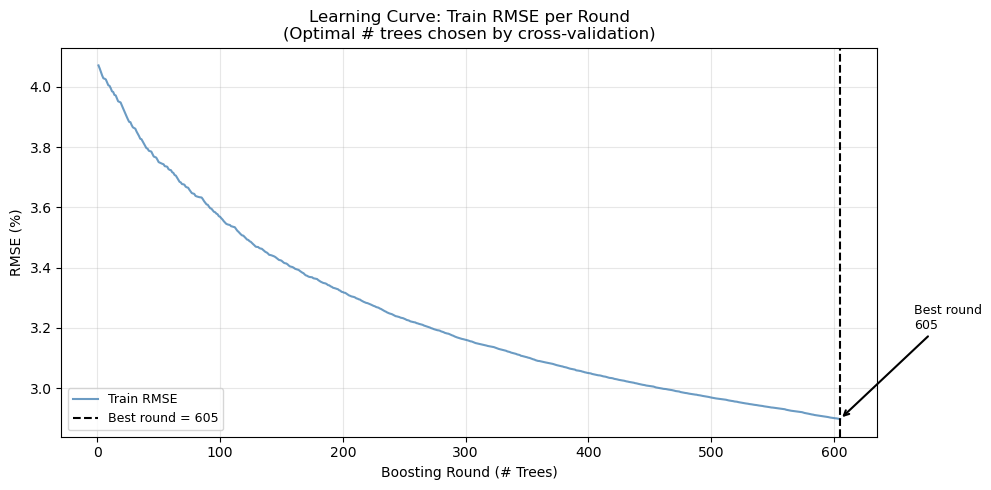

In [ ]:
def plot_learning_curve(evals_result, best_round):
    fig, ax = plt.subplots(figsize=(10, 5))
    train_rmse = evals_result['train']['rmse']
    rounds     = range(1, len(train_rmse) + 1)

    ax.plot(rounds, train_rmse, color='steelblue', linewidth=1.5,
            label='Train RMSE', alpha=0.8)
    ax.axvline(best_round, color='black', linestyle='--', linewidth=1.5,
               label=f'Best round = {best_round}')
    ax.annotate(f'Best round\n{best_round}',
                xy=(best_round, min(train_rmse)),
                xytext=(best_round + max(10, len(train_rmse) // 10),
                        min(train_rmse) + 0.3),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                fontsize=9)
    ax.set_xlabel('Boosting Round (# Trees)')
    ax.set_ylabel('RMSE (%)')
    ax.set_title('Learning Curve: Train RMSE per Round\n'
                 '(Optimal # trees chosen by cross-validation)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()



    
plot_learning_curve(evals_result, best_round)

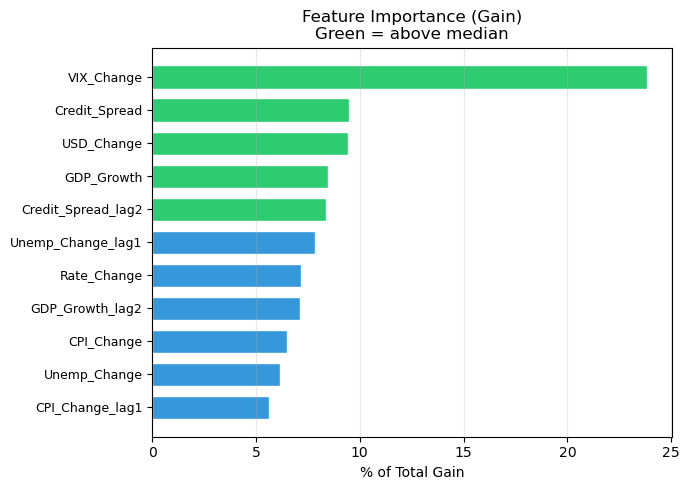

In [ ]:
def plot_feature_importance(imp_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    imp_plot = imp_df.sort_values('Gain_pct')
    bar_cols = ['#2ecc71' if g > imp_df['Gain_pct'].median() else '#3498db'
                for g in imp_plot['Gain_pct']]

    ax.barh(range(len(imp_plot)), imp_plot['Gain_pct'],
            color=bar_cols, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(imp_plot)))
    ax.set_yticklabels(imp_plot['Feature'], fontsize=9)
    ax.set_title('Feature Importance (Gain)\nGreen = above median')
    ax.set_xlabel('% of Total Gain')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

plot_feature_importance(imp_df)

    

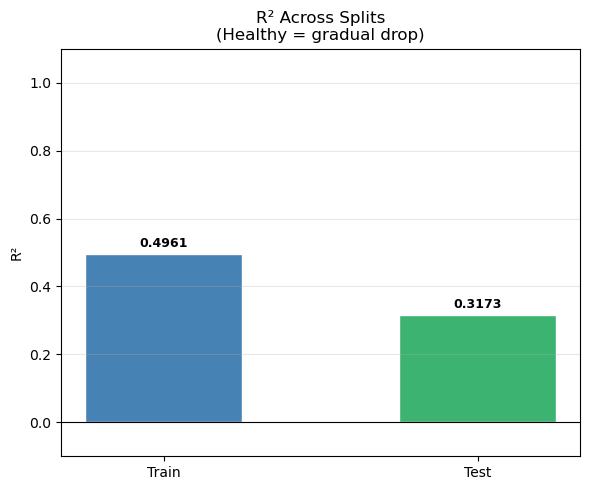

In [ ]:
def plot_r2_comparison(train_m, test_m):
    fig, ax = plt.subplots(figsize=(6, 5))
    splits  = ['Train', 'Test']
    r2_vals = [train_m['R2'], test_m['R2']]
    colors  = ['steelblue', 'mediumseagreen']

    bars = ax.bar(splits, r2_vals, color=colors, edgecolor='white', width=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('R² Across Splits\n(Healthy = gradual drop)')
    ax.set_ylabel('R²')
    ax.set_ylim(min(0, min(r2_vals)) - 0.1, 1.1)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()

plot_r2_comparison(train_m, test_m)

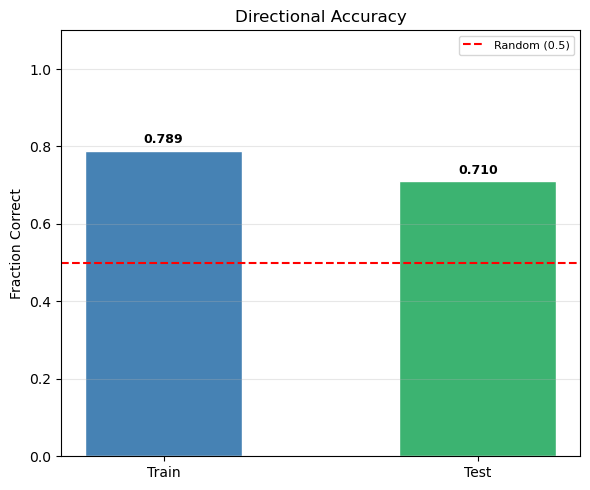

In [ ]:
def plot_directional_accuracy(train_m, test_m):
    fig, ax = plt.subplots(figsize=(6, 5))
    splits  = ['Train', 'Test']
    da_vals = [train_m['Dir_Acc'], test_m['Dir_Acc']]
    colors  = ['steelblue', 'mediumseagreen']

    bars = ax.bar(splits, da_vals, color=colors, edgecolor='white', width=0.5)
    ax.axhline(0.50, color='red', linestyle='--', linewidth=1.5, label='Random (0.5)')
    ax.set_ylim(0, 1.1)
    ax.set_title('Directional Accuracy')
    ax.set_ylabel('Fraction Correct')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, da_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()

plot_directional_accuracy(train_m, test_m)